# Day 08. Exercise 04
# Regression

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
import seaborn as sns

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [2]:
df = pd.read_csv(
    '../data/checker_regression.csv',
)
df = df.drop_duplicates('uid')

In [3]:
df.fillna(0, inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,0.0
1,user_10,20,89.0,0.0
2,user_11,7,0.0,-2.0
3,user_12,86,0.0,-89.0
4,user_13,52,0.0,-48.5


In [4]:
X = df.drop(columns=['AVG(diff)','uid'])
y = df['AVG(diff)']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=21)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [5]:
def crossval(n_splits, X,y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    
    train_rmse_list = []
    test_rmse_list = []
    
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        model.fit(X_train, y_train)
                
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        
        train_rmse_list.append(train_rmse)
        test_rmse_list.append(test_rmse)
        print(f"train - {train_rmse:.14f}  |  test - {test_rmse:.14f}")
    
    avg_rmse = np.mean(test_rmse_list)
    print(f"Average RMSE on crossval is {avg_rmse:.14f}")


In [6]:
linReg = LinearRegression()
crossval(10,X,y,linReg)

train - 61.35327112662008  |  test - 57.85614740884658
train - 62.54623351948630  |  test - 44.71218893425673
train - 61.14556371253599  |  test - 83.19897138394585
train - 58.41672862619424  |  test - 79.39901597711400
train - 60.11026827841826  |  test - 68.75614618929599
train - 60.61932302839534  |  test - 65.92296908962915
train - 61.72075104991357  |  test - 61.80036055301570
train - 62.60680682836641  |  test - 46.68994292992783
train - 55.58034321272078  |  test - 99.08124434288634
train - 61.57793245106181  |  test - 53.24118830442656
Average RMSE on crossval is 66.06581751133447


In [7]:
DTR = DecisionTreeRegressor(max_depth=1,random_state=21)
crossval(10,X,y,DTR)

train - 50.03169785176749  |  test - 44.66616643875419
train - 50.46179554040189  |  test - 40.05111405235178
train - 52.26261190978192  |  test - 0.00000000000000
train - 46.62409160654697  |  test - 69.51531831107476
train - 48.11196303602137  |  test - 60.17337183321023
train - 49.75273646400820  |  test - 47.15711390582638
train - 52.26261190978192  |  test - 0.00000000000000
train - 48.53500626695471  |  test - 60.35176228670635
train - 44.19970820184456  |  test - 83.80470412413216
train - 51.26526079535142  |  test - 5.46759919923363
Average RMSE on crossval is 41.11871501512896


In [8]:
RFR = RandomForestRegressor(n_estimators= 220,max_depth=1,random_state=21)
crossval(10,X,y,RFR)

train - 50.08660916230038  |  test - 44.99424584625963
train - 50.35514350966561  |  test - 40.06798399662446
train - 52.43846032809501  |  test - 18.01919635905748
train - 46.62465093604082  |  test - 69.24333602124372
train - 48.27221708220932  |  test - 60.35081132863501
train - 49.55202198371321  |  test - 48.01609547115946
train - 51.84431802512150  |  test - 9.35656949537691
train - 48.61251695728796  |  test - 60.05630303629081
train - 44.15736105836323  |  test - 84.15278004479757
train - 51.40984056307803  |  test - 22.91557603936425
Average RMSE on crossval is 45.71728976388092


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [9]:
linReg.fit(X_train,y_train)
y_pred = linReg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"linReg accuracy: {rmse}")

linReg accuracy: 52.69818584468257


In [10]:
def printScatter(y_true, y_pred):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
    plt.xlabel("Фактическая разница (True)")
    plt.ylabel("Предсказание (Predicted)")
    plt.show()

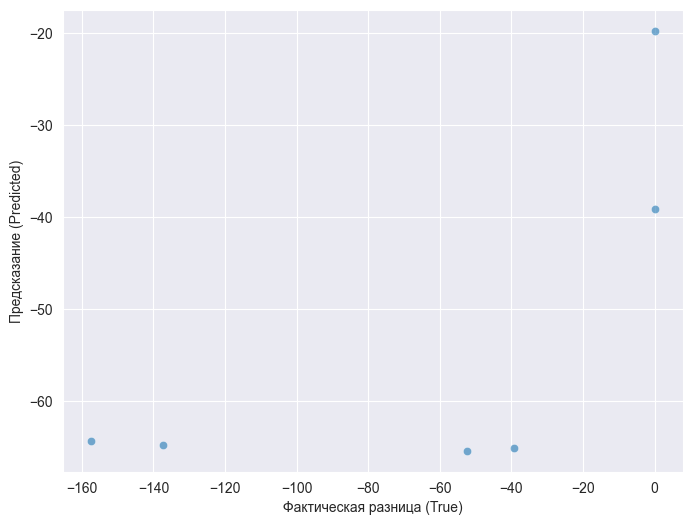

In [11]:
printScatter(y_test, y_pred)

In [12]:
DTR.fit(X_train,y_train)
y_pred = DTR.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"DTR accuracy: {rmse}")

DTR accuracy: 42.361971951403405


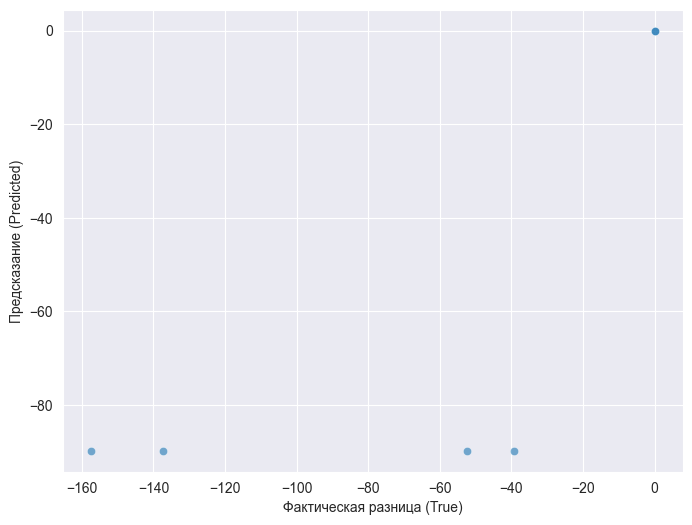

In [13]:
printScatter(y_test, y_pred)

In [14]:
RFR.fit(X_train,y_train)
y_pred = RFR.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RFR accuracy: {rmse}")

RFR accuracy: 42.336631948038104


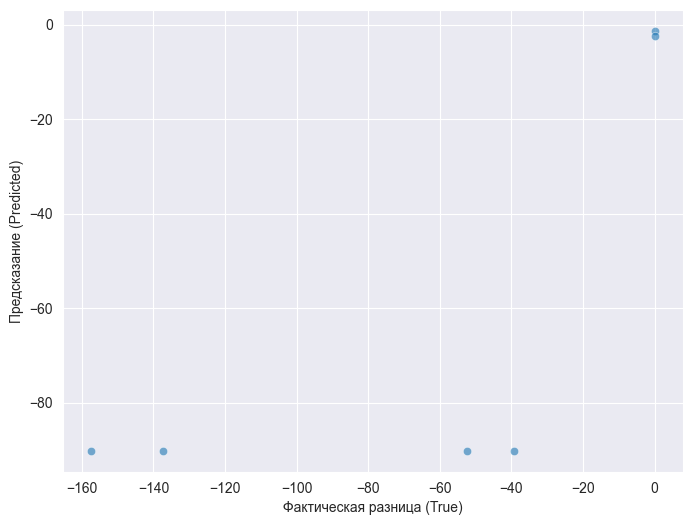

In [15]:
printScatter(y_test, y_pred)

## Как бы выглядел график в идеальном случае?

Ответ: он бы выглядел как просто диагональ